<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK10_1_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **7장 시계열 분석**

# 7.1 시계열

- 시계열 분석
  - 시간에 따라 변화하는 데이터를 이용해 추세 파악 및 미래 예측을 수행하는 분석 방법임
- 시계열 구성요소
  - 데이터 변동 유형에 따라 구분됨
    - 불규칙 변동: 규칙성이 없고 예측 불가능한 우발적 변동을 의미 (전쟁, 자연재해 등 포함)
    - 추세 변동: 장기적으로 증가·감소 또는 일정 상태를 유지하려는 경향을 나타내는 변동 (GDP, 인구 증가 등)
    - 순환 변동: 2~3년 이상의 비교적 긴 주기를 가지며 경기 변동과 같이 반복적으로 나타나는 변동
    - 계절 변동: 1년 주기로 계절적 요인이나 사회적 관습에 의해 반복되는 변동
- 시계열 데이터 분류
    - 규칙적 시계열
      - 트렌드와 분산이 일정한 데이터 형태
    - 불규칙 시계열
      - 트렌드 또는 분산이 시간에 따라 변하는 데이터 형태
- 시계열 분석 목적
  - 불규칙성을 가진 데이터에서 규칙적 패턴을 찾고 예측 수행
- 전통적 모델
  - AR, MA, ARMA, ARIMA 모델을 활용한 분석 방법
- 최신 접근법
  - 딥러닝을 활용하여 시계열 데이터의 패턴과 연속성을 자동으로 학습하는 방법

# 7.2 AR, MA, ARMA, ARIMA

- 독립변수를 사용하여 종속변수를 예측하는 일반적 머신러닝에서 '시간'을 독립변수로 사용

## 7.2.1 AR 모델

- 자기 회귀 모델
- 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어

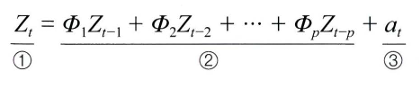

1.  현재 시점
2.  과거가 현재에 미치는 영향을 나타내는 모수에 시계열 데이터의 과거 시점(Z)을 곱한 것
3.  오차 항 = 백색 잡음

## 7.2.2 MA 모델

- 이동 평균 모델
- 트렌드가 변화하는 상황에 적합

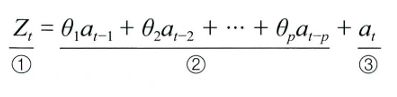

1.  현재 시점
2.  매개변수에 과거 시점의 오차(alpha)를 곱한 것
3.  오차 항

> 즉, AR 모델처럼 이전 데이터의 **상태**에서 현재 데이터의 상태를 추론하는 것이 아닌, 이전 데이터의 **오차**에서 현재 데이터의 상태를 추론하겠다는 의미

## 7.2.3 ARMA 모델

- 자기 회귀 이동 평균
- AR + MR
- 두 가지 관점에서 과거의 데이터를 사용하는 것

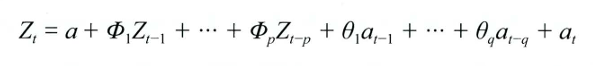

## 7.2.4 ARIMA 모델

- 자기 회귀 누적 이동 평균
- ARMA와 달리 과거 데이터의 선형 관계뿐만 아니라 추세까지 고려

**1.  ARIMA(p,d,q) 함수 호출**
  - p: 자기 회귀 차수
  - d: 차분 지수
  - q: 이동 평균 차수

**2.  fit() 메서드 호출**
  - 모델에 데이터를 적용하여 훈련

**3.  predict() 메서드 호출**
  - 미래의 추세 및 동향 예측

In [1]:
!pip install statsmodels

Mounted at /content/drive


/tmp/ipykernel_509/3331576496.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('/content/drive/MyDrive/ESAA/sales.csv', header=0, parse_dates=[0],
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Mon, 04 May 2026   AIC                            411.302
Time:                        06:56:11   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

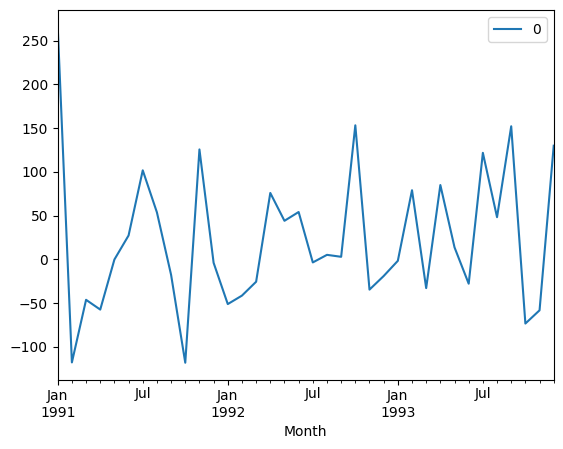

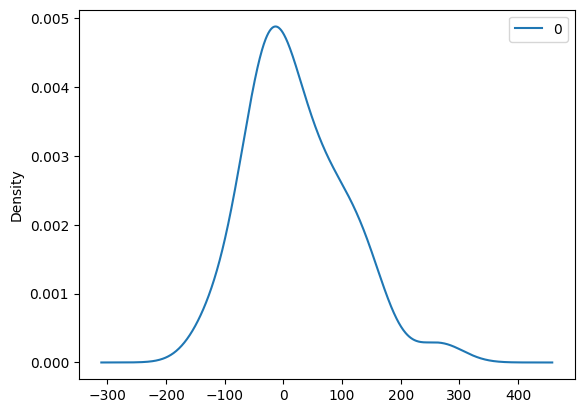

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [3]:
# 7-1 ARIMA 함수를 호출하여 sales 데이터셋에 대한 예측
from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):   # 시간을 표현하는 함수 정의
  return datetime.strptime('199'+x, '%Y-%m')   # strptime() = 날짜와 시간 정보를 문자열로 바꿔줌

from google.colab import drive
drive.mount('/content/drive')

series = read_csv('/content/drive/MyDrive/ESAA/sales.csv', header=0, parse_dates=[0],
                  index_col=0, date_parser=parser)
model = ARIMA(series, order=(5,1,0))   # ARIMA 함수 호출
model_fit = model.fit()
print(model_fit.summary())
residuals = DataFrame(model_fit.resid)
residuals.plot()   #  residuals 정보를 시각적으로 표현
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

- 오류 분포 결과를 보면 값이 치우쳐 있음을 확인할 수 있음
  - mean이 0이 아님

/tmp/ipykernel_509/2033509964.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('/content/drive/MyDrive/ESAA/sales.csv', header=0, parse_dates=[0],
/tmp/ipykernel_509/2033509964.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs))


predicted=352.855343, expected=346.300000
predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818


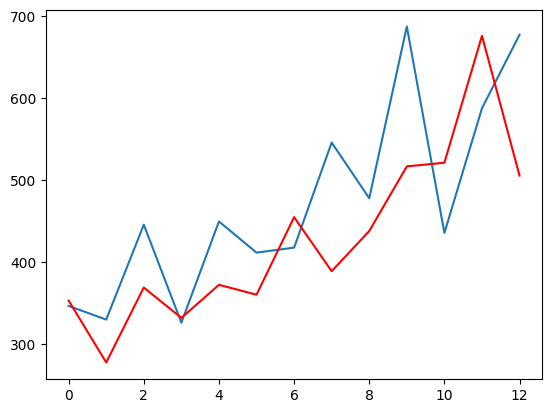

In [4]:
# 7-2 statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
  return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('/content/drive/MyDrive/ESAA/sales.csv', header=0, parse_dates=[0],
                  index_col=0, date_parser=parser)

X = series.values
X = np.nan_to_num(X)
size = int(len(X)*0.66)
train, test = X[0:size], X[size:len(X)]   # train과 test로 데이터셋 분리
history = [x for x in train]
predictions = list()

for t in range(len(test)):   # test 데이터셋의 길이(13)만큼 반복하여 수행
  model = ARIMA(history, order=(5,1,0))   # ARIMA() 함수 호출
  model_fit = model.fit()
  output = model_fit.forecast()   # forecast() 메서드를 사용하여 예측 수행
  yhat = output[0]   # 모델 출력 결과를 yhat에 저장
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs))
  # 모델 실행 결과를 predicted로 출력하고，test로 분리해 둔 데이터를 expected로 사용하여 출력

error = mean_squared_error(test, predictions)
print('Test MSE: %.3f'%error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

# 7.3 순환 신경망(RNN)

- RNN은 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망
- 이전 은닉층이 현재 은닉층의 입력이 되며 반복되는 순환 구조를 가짐
- 기억을 가진다는 점이 기존 네트워크와 다른 점
  - 기억 = 현재까지 입력 데이터를 요약한 정보
  - 새로운 입력이 네트워크로 들어올 때마다 기억은 조금씩 수정됨
  - 결국 최종적으로 남겨진 기억 = 모든 입력 전체를 요약한 정보

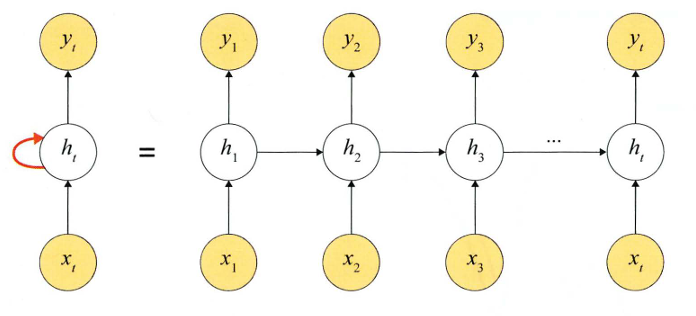

- 그림처럼, 첫번째 입력이 들어오면, 첫번째 기억(h1)이 만들어지고, 두번째 입력이 들어오면, 기존 기억(h1)과 새로운 입력을 참고하여 새 기억(h2)을 만듦
- 입력 길이만큼 이 과정을 얼마든지 반복 가능

< RNN 유형 >
- 일대일
  - 순환이 없기 때문에 RNN이라고 말하기 어려우며, 순방향 네트워크가 대표적 사례
- 일대다
  - 입력이 하나이고, 출력이 다수인 구조
  - 이미지를 입력해서 이미지에 대한 설명을 문장으로 출력하는 이미지 캡션이 대표적 사례
- 다대일
  - 입력이 다수이고 출력이 하나인 구조
  - 문장을 입력해서 긍정/부정을 출력하는 감성 분석기에서 사용
- 다대다
  - 입력과 출력이 다수인 구조
  - 언어를 번역하는 자동 번역기 등이 대표적 사례
- 동기화 다대다
  - 다대다 유형처럼 입력과 출력이 다수인 구조
  - 문장에서 다음에 나올 단어를 예측하는 언어 모델

< 다대일 모델 >

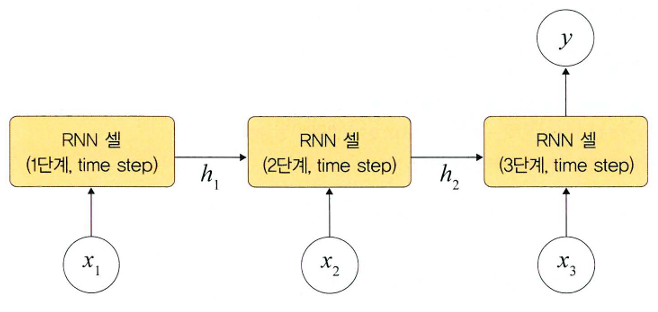

< 다대다 모델 >

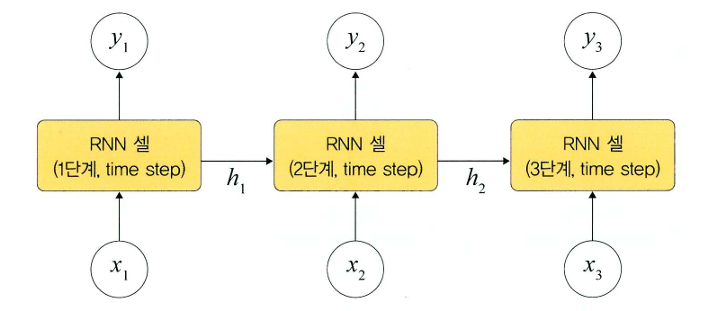

< 정리 >

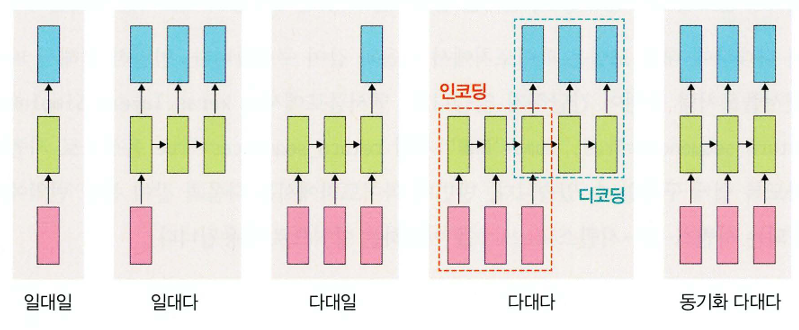

## 7.3.1 RNN 계층과 셀

- RNN은 내장된 계층뿐만 아니라 셀 레벨의 API 제공
- RNN 계층이 입력된 배치 순서대로 모두 처리하는 것과 다르게 RNN 셀은 오직 하나의 단계만 처리함
- 따라서 RNN셀은 RNN 계층의 for loop 구문을 갖는 구조

< 셀 유형 >
- nn.RNNCell: SimpleRNN 계층에 대응되는 RNN 셀
- nn.GRUCell: GRU 계층에 대응되는 GRU 셀
- nn.LSTMCell: LSTM 계층에 대응되는 LSTM 셀

< RNN 계층과 RNN 셀 >

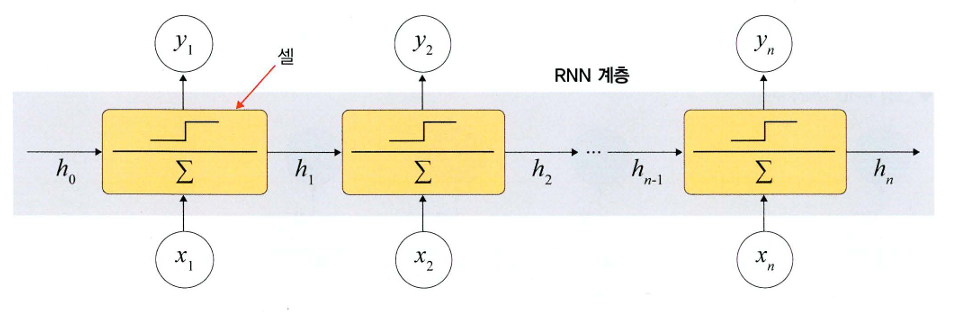